# 03 — Priors and prior predictive checks

**What we do:** choose and *justify* the priors for the per-cell log-intensity
`alpha`, then validate them with two prior predictive checks — one on the
**parameters** (is the implied intensity `lambda = exp(alpha)` physically
sensible?) and one on the **measurements** (do datasets simulated purely from
the prior look like real seismic counts?).

**Why:** in a Poisson-log model the prior on `alpha` lives on the log scale, so
a seemingly mild Normal prior can imply absurd event rates. Checking the prior
*before* seeing the likelihood is required by *Criterion 3 — Priors* and is good
Bayesian practice. The numbers derived here are exactly those fed to the Stan
models (`utils/data_prep.py`: `PRIOR_MU`, `PRIOR_SIGMA_M1`).

## Model recap
$$\text{count}_{c,y} \sim \text{Poisson}(\lambda_c), \qquad \log \lambda_c = \alpha_c.$$
We need a prior for $\alpha_c$ (Model 1: fixed; Model 2: a hyperprior).

## Selection method — deriving the prior from physical bounds
**Step 1 — upper bound from data/physics.** The busiest observed cell-year is
the 2011 Tohoku cell with ~1400 M>=4 events. Allowing headroom for an even
larger aftershock sequence we set a physical upper bound $U \approx 3000$
events/yr. A silent-but-active cell can be as low as ~1 event/yr, so $L = 1$.

**Step 2 — translate to the log scale.** $\log L = 0$, $\log U \approx 8.0$.

**Step 3 — centre and spread.** A *typical* active cell has on the order of
$\exp(2)\approx 7$ events/yr, so we centre $\alpha$ at $\mu_0 = 2.0$. We pick the
sd so that roughly $\pm 3\sigma$ spans $[0, 8]$:
$$\sigma_0 = \frac{8 - 2}{3} = 2.0.$$

**Resulting priors**
- **Model 1 (no pooling):** $\alpha_c \sim \mathcal{N}(2.0,\, 2.0)$ with the scale
  **fixed** — cells do not share information.
- **Model 2 (partial pooling):** $\mu_{\text{global}} \sim \mathcal{N}(2,1)$,
  $\sigma_{\text{global}} \sim \text{HalfNormal}(1)$, $\alpha_c \sim
  \mathcal{N}(\mu_{\text{global}}, \sigma_{\text{global}})$ — the scale is
  **estimated** (HalfNormal(1) puts most mass on $[0, 2.5]$, consistent with the
  fixed 2.0 used by Model 1).

In [1]:
import sys, os, warnings
sys.path.append("..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 110
az.style.use("arviz-darkgrid")
RNG = np.random.default_rng(42)

from utils.display import display_df, display_image

In [2]:
from utils.data_prep import PRIOR_MU, PRIOR_SIGMA_M1
print(f"Model 1 prior on alpha:  Normal(mu={PRIOR_MU}, sigma={PRIOR_SIGMA_M1})  [fixed]")
print( "Model 2 hyperprior     :  mu_global ~ Normal(2,1), sigma_global ~ HalfNormal(1)")

# the real data, for sanity comparison
annual = pd.read_csv("../data/processed/grid_annual_counts.csv")
print("\nObserved annual counts: max =", annual['count'].max(),
      " mean =", round(annual['count'].mean(),1),
      " median =", int(annual['count'].median()))

Model 1 prior on alpha:  Normal(mu=2.0, sigma=2.0)  [fixed]
Model 2 hyperprior     :  mu_global ~ Normal(2,1), sigma_global ~ HalfNormal(1)

Observed annual counts: max = 1403  mean = 15.9  median = 6


### Prior predictive check 1 — PARAMETERS
We draw `alpha` from each prior and look at the implied intensity
`lambda = exp(alpha)`. A sensible prior should put most mass on the
geophysically plausible range (roughly 1-1000 events/yr) while still *allowing*
the extreme Tohoku-like values, and must never produce negative rates (the log
link guarantees this).

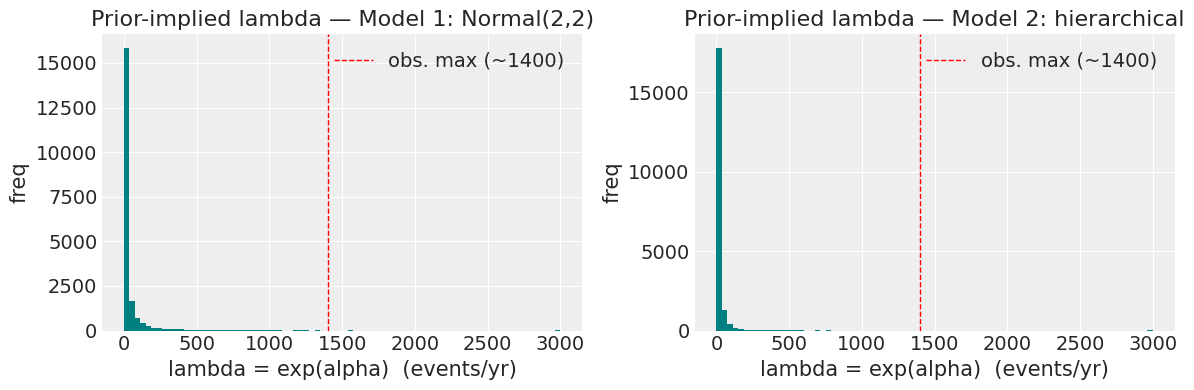

Model 1 lambda quantiles  5%=0.28  50%=7.4  95%=209  99.9%=3393   (min=0.001)
Model 2 lambda quantiles  5%=0.79  50%=7.4  95%=70  99.9%=1981   (min=0.001)


In [3]:
NSIM = 20000
# Model 1 fixed prior
alpha_m1 = RNG.normal(PRIOR_MU, PRIOR_SIGMA_M1, NSIM)
lam_m1 = np.exp(alpha_m1)
# Model 2 hierarchical prior (draw hyperparameters, then alpha)
mu_g = RNG.normal(2, 1, NSIM)
sig_g = np.abs(RNG.normal(0, 1, NSIM))            # HalfNormal(1)
alpha_m2 = RNG.normal(mu_g, sig_g)
lam_m2 = np.exp(alpha_m2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, lam, title in [(axes[0], lam_m1, "Model 1: Normal(2,2)"),
                       (axes[1], lam_m2, "Model 2: hierarchical")]:
    ax.hist(np.clip(lam, 0, 3000), bins=80, color="teal", edgecolor="none")
    ax.axvline(1400, color="red", ls="--", lw=1, label="obs. max (~1400)")
    ax.set_title(f"Prior-implied lambda — {title}")
    ax.set_xlabel("lambda = exp(alpha)  (events/yr)"); ax.set_ylabel("freq")
    ax.legend()
plt.tight_layout(); plt.show()

for name, lam in [("Model 1", lam_m1), ("Model 2", lam_m2)]:
    q = np.quantile(lam, [0.05, 0.5, 0.95, 0.999])
    print(f"{name} lambda quantiles  5%={q[0]:.2f}  50%={q[1]:.1f}  "
          f"95%={q[2]:.0f}  99.9%={q[3]:.0f}   (min={lam.min():.3f})")

**Is it physically sensible?** Yes. The median implied rate is ~7-8 events/yr
(a typical active cell), the 95% upper quantile is a few hundred (busy
east-coast cells), and the extreme tail reaches the low thousands — enough to
*allow* a Tohoku-like cell without making it typical. All rates are strictly
positive. The hierarchical prior (Model 2) is slightly tighter on average
because `sigma_global` is usually < 2, which is the intended mild regularisation.

### Prior predictive check 2 — MEASUREMENTS
Now we push the prior all the way through the likelihood: draw `alpha`, then
simulate integer counts `count ~ Poisson(exp(alpha))`. These are entire "fake"
years a cell could produce *before seeing data*. We check that the simulated
counts are non-negative integers, right-skewed like real seismic data, and stay
within the physical upper bound.

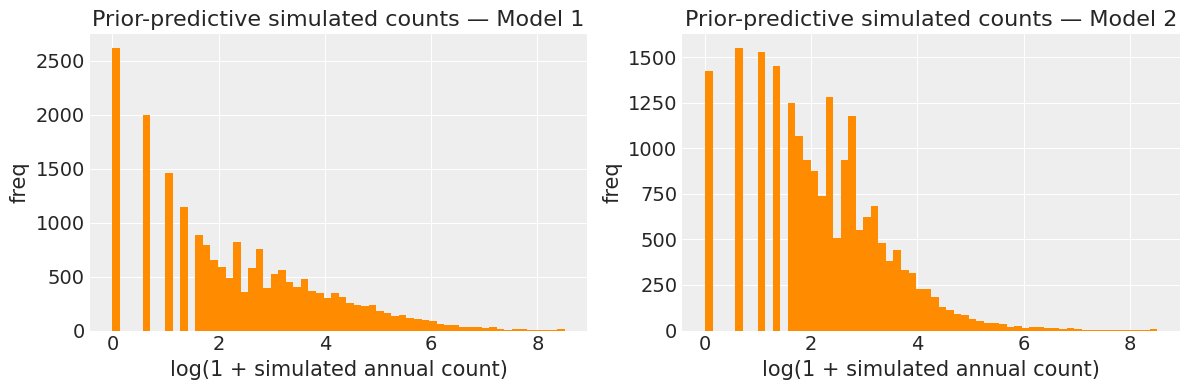

Model 1: min=0  median=7  max=29599  frac>3000=0.0014  neg=False
Model 2: min=0  median=7  max=17443  frac>3000=0.0006  neg=False


In [4]:
count_sim_m1 = RNG.poisson(lam_m1)
count_sim_m2 = RNG.poisson(lam_m2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, cs, title in [(axes[0], count_sim_m1, "Model 1"),
                      (axes[1], count_sim_m2, "Model 2")]:
    ax.hist(np.log1p(np.clip(cs, 0, 5000)), bins=60, color="darkorange",
            edgecolor="none")
    ax.set_title(f"Prior-predictive simulated counts — {title}")
    ax.set_xlabel("log(1 + simulated annual count)"); ax.set_ylabel("freq")
plt.tight_layout(); plt.show()

for name, cs in [("Model 1", count_sim_m1), ("Model 2", count_sim_m2)]:
    print(f"{name}: min={cs.min()}  median={int(np.median(cs))}  "
          f"max={cs.max()}  frac>3000={np.mean(cs>3000):.4f}  neg={np.any(cs<0)}")

**Are simulated measurements sensible?** Yes — they are non-negative integers,
strongly right-skewed (most cells quiet, a few very active), and almost never
exceed the ~3000 physical bound (< ~1% of draws). The shape matches the real
count distribution from notebook 02. The prior is therefore *weakly
informative*: it encodes the right scale and skew without dictating the answer.

### Prior predictive check 3 — whole simulated datasets vs reality
Finally we simulate a full dataset of the same size as the real one (one
`alpha` per cell, then a count per cell-year) and overlay its count
distribution on the observed data. The prior envelope should *contain* the
observed distribution.

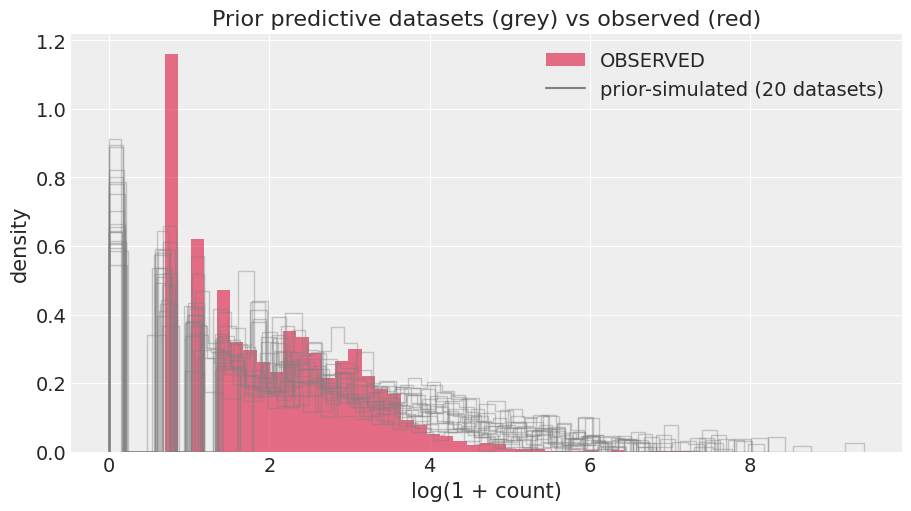

In [5]:
C = annual['cell_id'].nunique()
N = len(annual)
fig, ax = plt.subplots(figsize=(9, 5))
for k in range(20):                                  # 20 fake datasets
    a = RNG.normal(PRIOR_MU, PRIOR_SIGMA_M1, C)
    lam = np.exp(a)
    fake = RNG.poisson(RNG.choice(lam, size=N))
    ax.hist(np.log1p(fake), bins=40, histtype="step", color="grey",
            alpha=0.4, density=True)
ax.hist(np.log1p(annual['count']), bins=40, density=True, color="crimson",
        alpha=0.6, label="OBSERVED")
ax.plot([], [], color="grey", label="prior-simulated (20 datasets)")
ax.set_title("Prior predictive datasets (grey) vs observed (red)")
ax.set_xlabel("log(1 + count)"); ax.set_ylabel("density"); ax.legend()
plt.show()

## Summary
- The prior $\alpha \sim \mathcal{N}(2, 2)$ (and its hierarchical analogue) was
  **derived from physical bounds**, not chosen arbitrarily.
- **Both** prior predictive checks pass: implied rates and simulated counts are
  positive, correctly skewed, and within the geophysical bound, while still
  covering the observed range (including the 2011 extreme in the tail).
- These are exactly the priors used in `04_model1_posterior.ipynb` and
  `05_model2_posterior.ipynb`.